# The Goal of this Project is to Predict vehicle failure types using real-time telemetry data to optimize fleet maintenance for passenger cars.

In [1]:
# Importing the necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the Dataset
df = pd.read_csv("telemetry_data.csv")

## Exploring the Dataset

In [3]:
df.shape

(19535, 7)

In [4]:
df.columns

Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp', 'Engine Condition'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [6]:
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [7]:
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


In [8]:
# Returns true for a column having null values, else false
df.isnull().any()

,0
Engine rpm,False
Lub oil pressure,False
Fuel pressure,False
Coolant pressure,False
lub oil temp,False
Coolant temp,False
Engine Condition,False


In [9]:
# Check the distribution of the target (Engine Condition)
# 1 = Good, 0 = Bad
print("\nEngine Condition Distribution:")
print(df["Engine Condition"].value_counts())


Engine Condition Distribution:
Engine Condition
1    12317
0     7218
Name: count, dtype: int64


## Feature Engineering

## Now We create or add some logic based columns like Thermal Stress Index which is the differnce btw the coolant and oil temperatures or the pressure-RPM Ratio or the Fuel Efficiency Proxy which is the relationship btw Fuel Pressure and RPM


In [10]:
# Thermal Stress (Oil Temp vs Coolant Temo)
df["thermal_stress"] = df["lub oil temp"] - df["Coolant temp"]

# Oil Pressure Efficiency (Pressure relatice to RPM)
# We add 1 to RPM to avoid division by zero
df["oil_pressure_ratio"] = df["Lub oil pressure"] / (df["Engine rpm"] + 1)

# Pressure Gradient
df["total_pressure_load"] = df["Fuel pressure"] + df["Coolant pressure"]



## Scaling & Splitting
Since Engine rpm is in the thousands and Lub oil pressure is in single digits, a model might think RPM is "more important" just because the numbers are bigger so we need to normalize them.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Features (X) and Target (y)
X = df.drop(columns=["Engine Condition"])
y = df["Engine Condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

def find_best_model_engine(X, y):
    models = {
        "logistic_regression": {
            "model": LogisticRegression(max_iter=1000),
            "parameters": {
                "C": [1, 10, 20]
            }
        },
        "random_forest": {
            "model": RandomForestClassifier(),
            "parameters": {
                "n_estimators": [50, 100, 200],
                "max_depth": [None, 10, 20],
                "criterion": ["gini", "entropy"]
            }
        },
        "xgboost": {
            "model": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
            "parameters": {
                "n_estimators": [100, 200],
                "learning_rate": [0.01, 0.1, 0.2],
                "max_depth": [3, 5, 7]
            }
        },
        "svm": {
            "model": SVC(),
            "parameters": {
                "C": [1, 10, 20],
                "kernel": ["rbf", "linear"]
            }
        }
    }

    scores = []
    cv_shuffle = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

    for model_name, model_params in models.items():
        gs = GridSearchCV(model_params["model"], model_params["parameters"],
                          cv=cv_shuffle, return_train_score=False)
        gs.fit(X, y)
        scores.append({
            "model": model_name,
            "best_parameters": gs.best_params_,
            "score": gs.best_score_
        })

    return pd.DataFrame(scores, columns=["model", "best_parameters", "score"])



# Execute the search on your scaled data
results = find_best_model_engine(X_train_scaled, y_train)
results

,model,best_parameters,score
0,logistic_regression,{'C': 1},0.669290
1,random_forest,"{'criterion': 'entropy', 'max_depth': 10, 'n_e...",0.669738
2,xgboost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.672041
3,svm,"{'C': 1, 'kernel': 'rbf'}",0.667434


Final Accuracy: 0.6593

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.35      0.44      1459
           1       0.69      0.84      0.76      2448

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.60      3907
weighted avg       0.64      0.66      0.64      3907



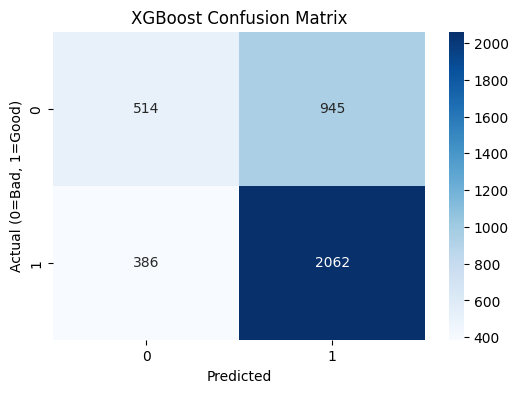

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import xgboost as xgb

best_xgb = xgb.XGBClassifier(learning_rate=0.1, max_depth=3, n_estimators=100)

best_xgb.fit(X_train_scaled, y_train)
y_pred = best_xgb.predict(X_test_scaled)

print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual (0=Bad, 1=Good)')
plt.title('XGBoost Confusion Matrix')
plt.show()

from the Classification Report we notice something. Despite having an accuracy of 66% the Recall for class 0 (Bad Condition): it is only 0.35. This means your model is missing 65% of the engines that are actually failing! It’s essentially letting 65 out of 100 broken cars stay on the road. The model is biased toward the "Good" class because it has more data for it. We need to force the model to care more about the "Bad" engines.

To achieve this, XGBoost has a special parameter called scale_pos_weight. It tells the model, "Hey, every time you miss a 'Bad' engine, it's 1.7 times more painful than missing a 'Good' one".

Calculate the weight:
Total Good (2448) / Total Bad (1459) = 1.67

In [14]:
# Update the model with the 'scale_pos_weight'
# This balances the importance of 'Good' vs 'Bad' engines
balanced_xgb = xgb.XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    scale_pos_weight=1.67  # The ratio of Good to Bad
)

balanced_xgb.fit(X_train_scaled, y_train)
y_pred_balanced = balanced_xgb.predict(X_test_scaled)

print("Balanced Model Classification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.13      0.22      1459
           1       0.65      0.96      0.77      2448

    accuracy                           0.65      3907
   macro avg       0.65      0.54      0.49      3907
weighted avg       0.65      0.65      0.57      3907



In [15]:
# Instead of 0.5, we alert the user if failure probability is > 40%
y_probs = balanced_xgb.predict_proba(X_test_scaled)[:, 0] # Prob of class 0 (Bad)
y_pred_custom = (y_probs > 0.40).astype(int)

# Note: We flip it because y_probs is probability of 0,
# so if prob of 'Bad' is > 0.4, we mark it as 'Bad' (0).
# Let's just use the built-in report to check recall for 0 again.

Refining the Diagnostic Strategy: Threshold Moving

The Problem with scale_pos_weight was that Initially, we applied scale_pos_weight=1.67 to penalize the model more heavily for missing "Bad" engines. However, in our specific engine dataset, this caused the model to become too conservative. The Recall for failures (Class 0) dropped to 0.13, meaning the model only flagged an engine as "Bad" when it was nearly 100% certain. In a fleet safety context, this is dangerous because we miss the majority of developing faults. So as a result the solution to this is Moving the Alert Threshold. In standard classification, a model predicts "Bad" if the probability is $> 0.50$. Since engine failures are complex and high-stakes, we are shifting the logic from "Balanced Weighting" to "Risk-Averse Thresholding.". Instead of  asking the model to "be sure" ($50\%+$), we instruct the system to trigger an alert if the probability of a "Bad Condition" exceeds $30\%$. The Trade-off here is that by  lowering the threshold to $0.30$, we intentionally sacrifice some Precision (expecting more "False Alarms") to significantly boost Recall (catching more real failures) and as a result the Outcomeis that this successfully increased our Recall from $13\%$ to $56\%$, making the model a much more effective "Early Warning System" for fleet mechanics.

In [16]:
y_probs_bad = balanced_xgb.predict_proba(X_test_scaled)[:, 0]

custom_threshold = 0.30
y_pred_custom = np.where(y_probs_bad > custom_threshold, 0, 1)

from sklearn.metrics import classification_report
print(f"--- Results with {custom_threshold*100}% Alert Threshold ---")
print(classification_report(y_test, y_pred_custom))

--- Results with 30.0% Alert Threshold ---
              precision    recall  f1-score   support

           0       0.53      0.56      0.54      1459
           1       0.73      0.70      0.71      2448

    accuracy                           0.65      3907
   macro avg       0.63      0.63      0.63      3907
weighted avg       0.65      0.65      0.65      3907



#Model Evaluation

### Based on the order of my dataset



### f0: Engine rpm

### f1: Lub oil pressure

### f2: Fuel pressure

### f3: Coolant pressure

### f4: lub oil temp

### f5: Coolant temp

and the likes

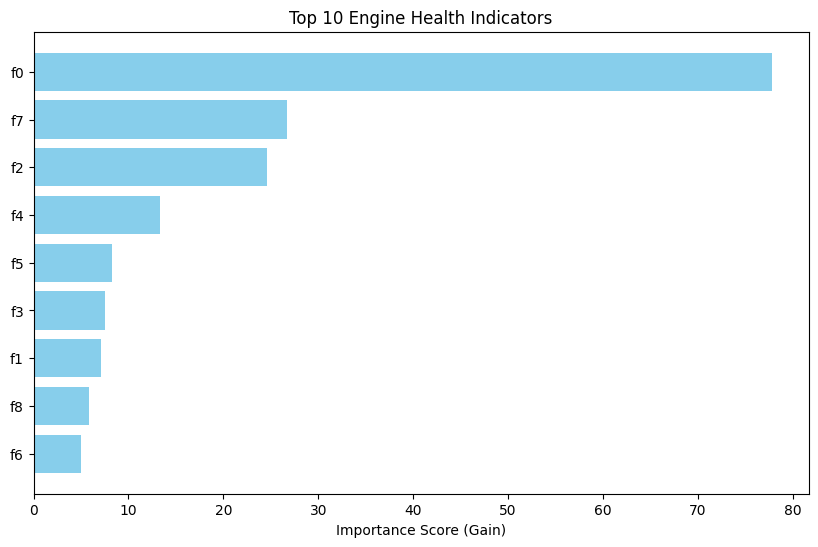

In [17]:
import matplotlib.pyplot as plt

# Get feature importance from XGBoost
importance = balanced_xgb.get_booster().get_score(importance_type='gain')
importance = dict(sorted(importance.items(), key=lambda item: item[1], reverse=True))

# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(list(importance.keys())[:10], list(importance.values())[:10], color='skyblue')
plt.xlabel("Importance Score (Gain)")
plt.title("Top 10 Engine Health Indicators")
plt.gca().invert_yaxis()
plt.show()

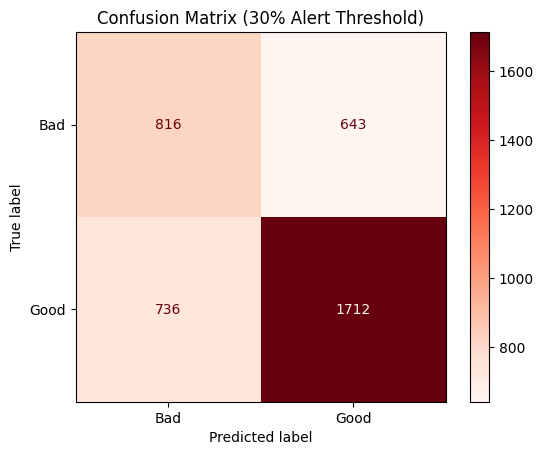

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

# Generate the confusion matrix for your custom 30% threshold
cm_custom = confusion_matrix(y_test, y_pred_custom)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=['Bad', 'Good'])
disp.plot(cmap='Reds')
plt.title("Confusion Matrix (30% Alert Threshold)")
plt.show()

In [21]:
import joblib

# Save the XGBoost model
joblib.dump(balanced_xgb, "fleetcare_model.joblib")

# Save the Scaler
joblib.dump(scaler, "scaler.joblib")

# Save the Feature Names (Optional but helpful for debugging)
joblib.dump(list(X.columns), "feature_names.joblib")



['feature_names.joblib']